In [10]:
import numpy as np
import nanosurf as nsf
from nanosurf.lib.util import gwy_export

def convert_nhf_to_gwy_raw(nhf_filepath: str, gwy_output_path: str):
    nhf_reader = nsf.util.nhf_reader.NHFFileReader(verbose=False)

    if not nhf_reader.read(nhf_filepath):
        raise IOError(f"Could not read NHF file: {nhf_filepath}")

    measurement = nhf_reader.measurements[0]
    segment = measurement.segment["Forward"]

    topo_channel = segment.channel["Topography"]
    raw_data = np.array(topo_channel.dataset)

    # Attempt to retrieve scaling factor
    # scale = topo_channel.attribute.get("scale", 1e-9)  # fallback to 1 nm/count
    # data_meters = raw_data * scale
    # data_nm = data_meters * 1e9  # Convert to nanometers for Gwyddion
    data_nm = raw_data * 2e-15 * 1.14 # Convert to nanometers for Gwyddion

    # xres = measurement.attribute['image_points_per_line']
    # yres = measurement.attribute['image_number_of_lines']
    # xreal = measurement.attribute['image_size_x']
    # yreal = measurement.attribute['image_size_y']

    xres = measurement.dataset_size_x
    yres = measurement.dataset_size_y
    xreal = measurement.dataset_range_x
    yreal = measurement.dataset_range_y

    data_nm_reshaped = np.flipud(data_nm.reshape((yres, xres)))

    size_info = gwy_export.GwySizeInfo(
        x_range=xreal,
        y_range=yreal,
        unit_xy="m"
    )

    if not gwy_export.savedata_gwy(
        gwy_output_path,
        size_info=size_info,
        data_sets=[data_nm_reshaped],
        data_labels=["Topography"],
        data_units=["nm"]
    ):
        raise IOError("Saving .gwy file failed.")

    print(f"\u2705 Converted: {gwy_output_path}")

In [11]:
print(f'{(512*1) / 1000} um')

0.512 um


In [12]:
print(f'{(512*1.5) / 1000} um')

0.768 um


In [13]:
print(f'{(512*2) / 1000} um')

1.024 um


In [14]:
print(f'{(512*2.5) / 1000} um')

1.28 um


In [15]:
import pathlib

In [16]:
afmPath = pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM')
afmPath.exists()

True

In [17]:
# for dir in sorted(afmPath.glob('20*')):
#     print(dir)

# dir = afmPath.joinpath('2024-05-29')
# dir = afmPath.joinpath('2024-05-28')
dir = afmPath.joinpath('2025-05-27')
dir

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/2025-05-27')

In [43]:
afmPath.joinpath('npys')

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/npys')

In [230]:
# afm_npys = sorted(afmPath.joinpath('npys').glob('*.npy'))
afm_npys = sorted(pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/npys').glob('*.npy'))
afm_npys

[PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/npys/PM6_CF_1.npy'),
 PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/npys/PM6_p5CNCF_1.npy'),
 PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/npys/PM6_p5CNCF_2.npy')]

In [69]:
import xarray as xr

In [232]:
afm_arr.shape

(500, 500)

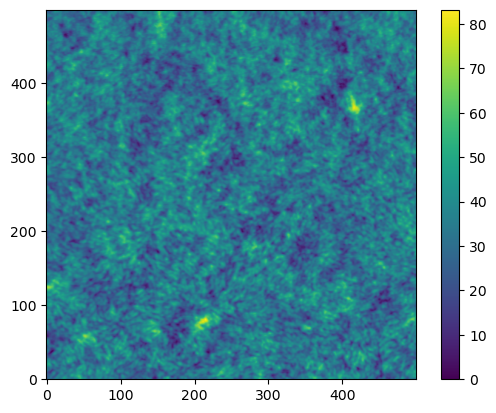

In [254]:
afm_arr = np.load(afm_npys[0]) * 1e10
# voxels_arr = (angstroms_arr/20).astype('int')

plt.imshow(afm_arr, origin='lower')
plt.colorbar()
plt.show()

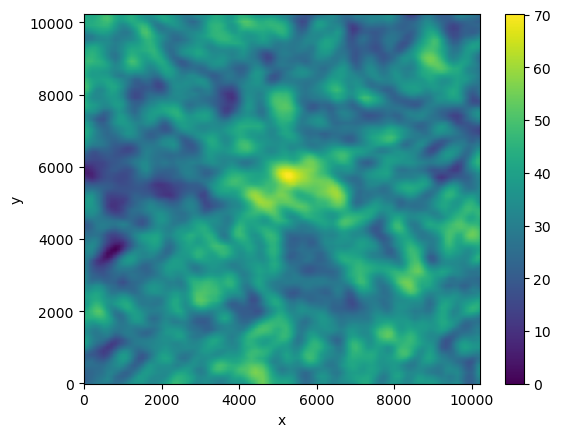

In [374]:
voxel_size = 20
ld = 512

x_offset = 0 * 1e4  # offset in angstroms for starting/ending slice of afm if necessary
y_offset = 0 * 1e4  # offset in angstroms for starting/ending slice of afm if necessary

# Interp to correct pixels/voxels
# afm_DA = xr.DataArray(data=afm_arr, coords={'y':np.linspace(0,50000,500), 'x':np.linspace(0,50000,500)}).sel(x=slice(x_offset*voxel_size, x_offset*voxel_size + voxel_size*ld),
#                                                                                                              y=slice(y_offset*voxel_size, y_offset*voxel_size + voxel_size*ld))

afm_DA = xr.DataArray(data=afm_arr, 
                      coords={'y':np.linspace(0,50000,500), 'x':np.linspace(0,50000,500)}).sel(
                      x=slice(x_offset, x_offset + voxel_size*ld), y=slice(y_offset, y_offset + voxel_size*ld))
afm_DA = afm_DA.interp({'x':np.linspace(afm_DA.x.min(),afm_DA.x.max(),512), 'y':np.linspace(afm_DA.y.min(),afm_DA.y.max(),512)})
afm_DA = afm_DA - afm_DA.min()
afm_DA.plot.imshow()

# afm_DA = np.round((afm_DA / voxel_size))
# afm_DA = (afm_DA / voxel_size)

# np.round((afm_DA / voxel_size)).plot.imshow()



# angstroms_arr = afm_arr*1e10
# voxels_arr = (angstroms_arr/20).astype('int')

# plt.imshow(angstroms_arr)
# plt.colorbar()
# plt.show()
# plt.imshow(voxels_arr)
# plt.colorbar()
# plt.show()

In [371]:
np.isnan(afm_DA.data).mean()

0.0

In [373]:
np.round((afm_DA / voxel_size))

<xarray.DataArray (y: 512, x: 512)>
array([[1., 1., 1., ..., 1., 1., 2.],
       [1., 1., 1., ..., 1., 1., 2.],
       [1., 1., 1., ..., 1., 2., 2.],
       ...,
       [2., 2., 2., ..., 1., 1., 1.],
       [2., 2., 2., ..., 1., 1., 1.],
       [2., 2., 2., ..., 1., 1., 1.]])
Coordinates:
  * x        (x) float64 0.0 20.0 40.0 60.0 ... 1.018e+04 1.02e+04 1.022e+04
  * y        (y) float64 0.0 20.0 40.0 60.0 ... 1.018e+04 1.02e+04 1.022e+04

In [386]:
upper_clip.shape

(512, 512, 10)

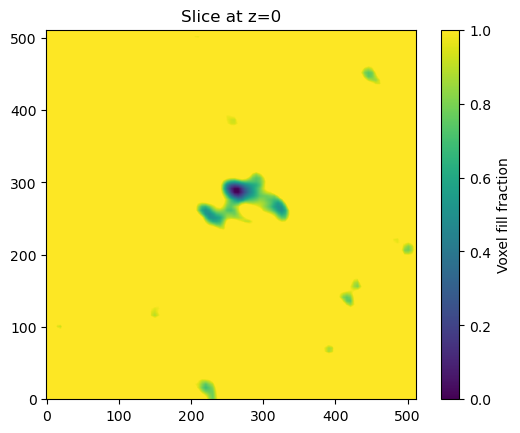

In [413]:
# afm_surf = np.round(afm_DA.data / voxel_size)
afm_surf = afm_DA.data / voxel_size

topo = afm_surf.max() - afm_surf
# topo = afm_surf
topo_3d = np.zeros((512,512,10))


# 1. Create Z layer indices (shape: [1, 1, 10])
z = np.arange(10).reshape(1, 1, 10)

# 2. Broadcast topography to shape (512, 512, 10)
topo_3d = topo[:, :, None]

# 3. Clip the topography above the *bottom* of each voxel
voxel_grid = np.clip(topo_3d - z, 0, 1)


# Visualize middle z slice
z = 0
plt.imshow(voxel_grid[:, :, z], origin='lower')
plt.colorbar(label='Voxel fill fraction')
plt.title(f"Slice at z={z}")
plt.show()

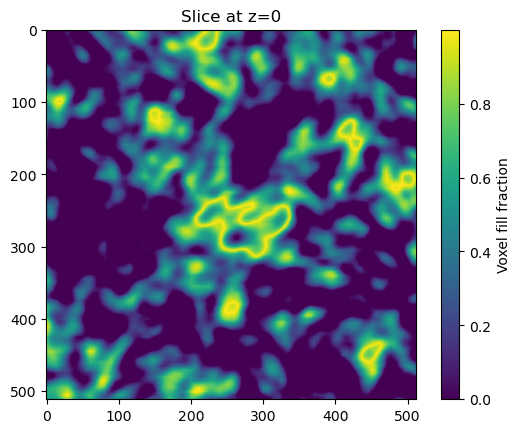

In [326]:
H, W = afm_DA.data.shape

# Convert depth to voxels
afm_surf = afm_DA.data / voxel_size
depth_surf = afm_surf.max() - afm_surf

# Create voxel centers along z
z = np.arange(mat2_Vfrac[0,0,:].size).reshape(1, 1, -1)  # shape: (1, 1, D)

# Broadcast topography height across z dimension
height_3d = depth_surf[:, :, None]  # shape: (H, W, 1)

# Compute fractional volume above surface
voxel_top = z + 1
voxel_bottom = z

voxel_grid = np.clip(height_3d - voxel_bottom, 0, 1) - np.clip(height_3d - voxel_top, 0, 1)

# Visualize middle z slice
z = 0
plt.imshow(voxel_grid[:, :, z])
plt.colorbar(label='Voxel fill fraction')
plt.title(f"Slice at z={z}")
plt.show()

In [303]:
frac.dtype

dtype('float64')

In [243]:
# import numpy as np
# import matplotlib.pyplot as plt

def afm_to_voxel_grid(height_map, grid_depth=10):
    """
    Convert a 2D AFM height map into a 3D voxel grid with partial surface values.

    Parameters:
        height_map (ndarray): 2D array of shape (H, W) with surface heights.
        grid_depth (int): Number of voxels along the z-axis (e.g., 10)

    Returns:
        ndarray: 3D array (H, W, D) of float32 values (0–1)
    """
    H, W = height_map.shape
    afm_min = height_map.min()
    afm_max = height_map.max()

    # Normalize to grid depth
    scaled_height = (height_map - afm_min) / (afm_max - afm_min) * grid_depth

    # Create voxel centers along z
    z = np.arange(grid_depth).reshape(1, 1, -1)  # shape: (1, 1, D)

    # Broadcast topography height across z dimension
    height_3d = scaled_height[:, :, None]  # shape: (H, W, 1)

    # Compute fractional volume above surface
    voxel_top = z + 1
    voxel_bottom = z

    frac = np.clip(height_3d - voxel_bottom, 0, 1) - np.clip(height_3d - voxel_top, 0, 1)

    return frac.astype(np.float32)

(512, 512, 10)


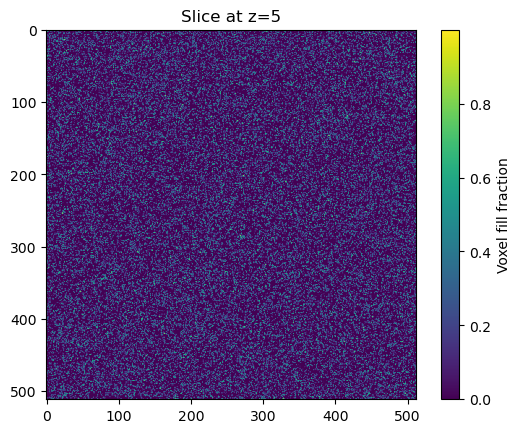

In [244]:
height_map = np.random.rand(512, 512) * 100  # simulate 100nm range
voxel_grid = afm_to_voxel_grid(height_map, grid_depth=10)

print(voxel_grid.shape)  # (512, 512, 10)

# Visualize middle z slice
plt.imshow(voxel_grid[:, :, 5])
plt.colorbar(label='Voxel fill fraction')
plt.title("Slice at z=5")
plt.show()

In [18]:
[f.name for f in sorted(dir.glob('*.nhf'))]

['PM6_1CNCF_1.nhf',
 'PM6_1CNCF_2.nhf',
 'PM6_1CNCF_3.nhf',
 'PM6_1CNCF_4.nhf',
 'PM6_1CNCF_5.nhf',
 'PM6_5CNCF_1.nhf',
 'PM6_5CNCF_2.nhf']

In [19]:
# filepath = dir.joinpath('PM6_CF_1.nhf')
filepath = dir.joinpath('PM6_1CNCF_1.nhf')
filepath.exists()

True

In [154]:
filepath

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/2024-05-28/PM6_CF_1.nhf')

In [167]:
# measurement.attribute

In [166]:
# nhf_filepath=filepath
# gwy_output_path=afmPath.joinpath(filepath.stem+'.gwy')

# nhf_reader = nsf.util.nhf_reader.NHFFileReader(verbose=False)

# if not nhf_reader.read(nhf_filepath):
#     raise IOError(f"Could not read NHF file: {nhf_filepath}")

# measurement = nhf_reader.measurements[0]
# segment = measurement.segment["Forward"]

# topo_channel = segment.channel["Topography"]
# raw_data = np.array(topo_channel.dataset)

# # Attempt to retrieve scaling factor
# # scale = topo_channel.attribute.get("scale", 1e-9)  # fallback to 1 nm/count
# # data_meters = raw_data * scale
# # data_nm = data_meters * 1e9  # Convert to nanometers for Gwyddion
# data_nm = raw_data * 2e-15 * 1.14 # Convert to nanometers for Gwyddion

# xres = measurement.attribute['image_points_per_line']
# yres = measurement.attribute['image_number_of_lines']
# xreal = measurement.attribute['image_size_x']
# yreal = measurement.attribute['image_size_y']

# data_nm_reshaped = np.flipud(data_nm.reshape((yres, xres)))

# size_info = gwy_export.GwySizeInfo(
#     x_range=xreal,
#     y_range=yreal,
#     unit_xy="m"
# )

# # if not gwy_export.savedata_gwy(
# #     gwy_output_path,
# #     size_info=size_info,
# #     data_sets=[data_nm_reshaped],
# #     data_labels=["Topography"],
# #     data_units=["nm"]
# # ):
# #     raise IOError("Saving .gwy file failed.")

# print(f"\u2705 Converted: {gwy_output_path}")

In [20]:
data_nm_reshaped.shape

NameError: name 'data_nm_reshaped' is not defined

In [21]:
for nhf_filepath in sorted(dir.glob('*.nhf')):
    nhf_reader = nsf.util.nhf_reader.NHFFileReader(verbose=False)

    if not nhf_reader.read(nhf_filepath):
        raise IOError(f"Could not read NHF file: {nhf_filepath}")

    measurement = nhf_reader.measurements[0]
    segment = measurement.segment["Forward"]

    topo_channel = segment.channel["Topography"]
    raw_data = np.array(topo_channel.dataset)

    # Attempt to retrieve scaling factor
    # scale = topo_channel.attribute.get("scale", 1e-9)  # fallback to 1 nm/count
    # data_meters = raw_data * scale
    # data_nm = data_meters * 1e9  # Convert to nanometers for Gwyddion
    data_nm = raw_data * 2e-15 * 1.14 # Convert to nanometers for Gwyddion

    # xres = measurement.attribute['image_points_per_line']
    # yres = measurement.attribute['image_number_of_lines']
    # xreal = measurement.attribute['image_size_x']
    # yreal = measurement.attribute['image_size_y']

    xres = measurement.dataset_size_x
    yres = measurement.dataset_size_y
    xreal = measurement.dataset_range_x
    yreal = measurement.dataset_range_y

    data_nm_reshaped = np.flipud(data_nm.reshape((yres, xres)))
    print(data_nm_reshaped.shape)

(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)


In [169]:
for filepath in sorted(dir.glob('*.nhf')):
    convert_nhf_to_gwy_raw(
        nhf_filepath=filepath,
        gwy_output_path=afmPath.joinpath(filepath.stem+'.gwy')
    )

✅ Converted: /Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/PM6_1CNCF_1.gwy
✅ Converted: /Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/PM6_1CNCF_2.gwy
✅ Converted: /Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/PM6_1CNCF_3.gwy
✅ Converted: /Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/PM6_1CNCF_4.gwy
✅ Converted: /Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/PM6_1CNCF_5.gwy
✅ Converted: /Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/writing/2024_papers/PM6_film_morphology_solvent_studies/PM6_AFM/PM6_5CNCF_1.gwy
✅ Converted: /Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/rese

In [117]:
2.2261 / 1.9512

1.1408876588765888